In [1]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
analysis_name = "Analysis_3"
analysis_dir = Path.cwd() 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
def get_kb_dir(project_dir: Path, assay: str, type: str = None) -> Path:
    if type is None:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / "sampled_out"
    else:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / f"sampled_{type}_out"
    return kb_dir

In [ ]:
sample = 'H1'

data_10x = plotting.init_processing(data_name=f"10x", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"10x"), data_title=f"{sample} 10X Genomics")
data_polyT = plotting.init_processing(data_name=f"polyT", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse", type="polyT"), data_title=f"{sample} Parse 3'")
data_randO = plotting.init_processing(data_name=f"randO", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse", type="randO"), data_title=f"{sample} Parse Random Oligo")
data_parse = plotting.init_processing(data_name=f"parse", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse"), data_title=f"{sample} Parse", modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]


# Population Upsampling Estimation

In [ ]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path(f"{sample}/preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path(f"{sample}/preseq"), xlim=5e8, ylim=8e4)

PreSeq running in background for: 10x_H1, polyT_H1, randO_H1, parse_H1
PreSeq output not ready for 'H1 10X Genomics' — skipping.
PreSeq output not ready for 'H1 Parse 3'' — skipping.
PreSeq output not ready for 'H1 Parse Random Oligo' — skipping.
PreSeq output not ready for 'H1 Parse' — skipping.
No PreSeq results available yet — rerun plot_upsample() when jobs complete.


# Quality Control Comparison

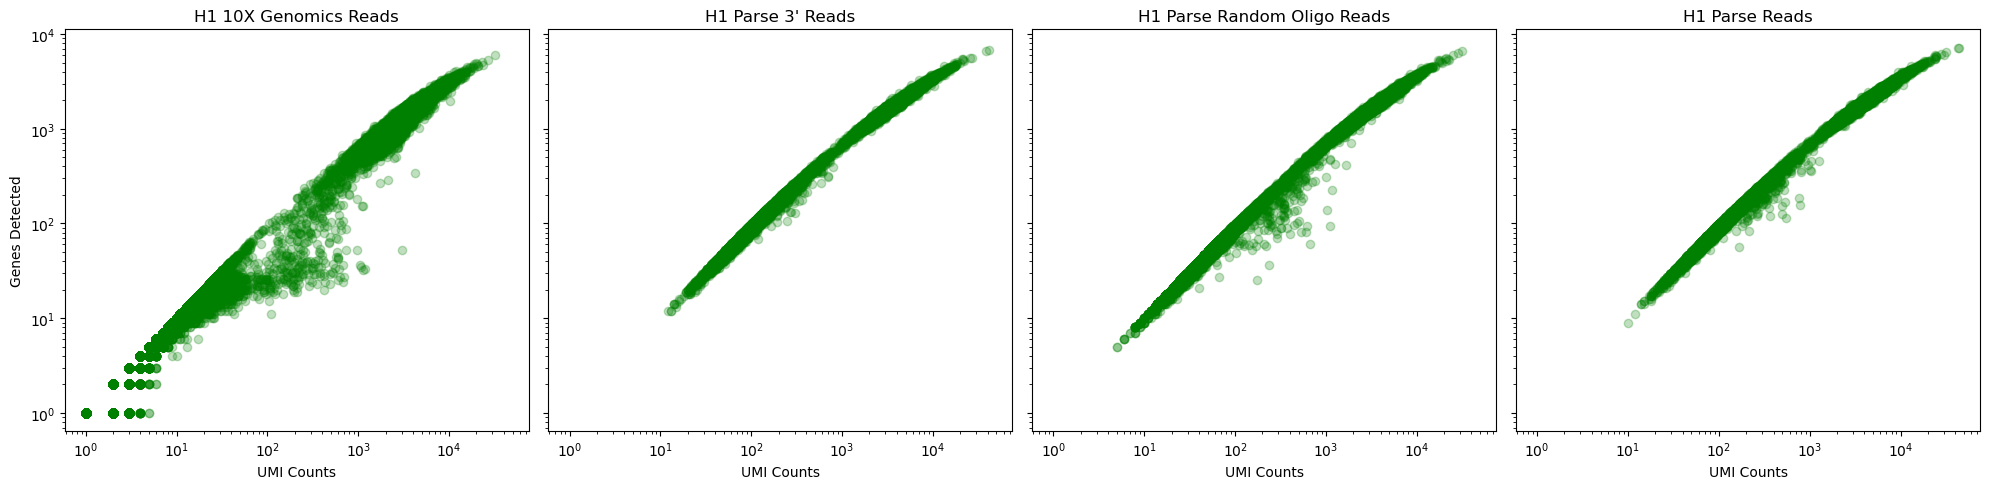

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(raw_datasets):
    plotting.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()


In [11]:
# Path to save gene metadata so don't need to query Ensembl 
# more than once
gene_info = plotting.query_ensembl(analysis_dir, species="hsapiens") 

In [12]:
for data in raw_datasets:
    data = plotting.add_cell_metrics(data, gene_info)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


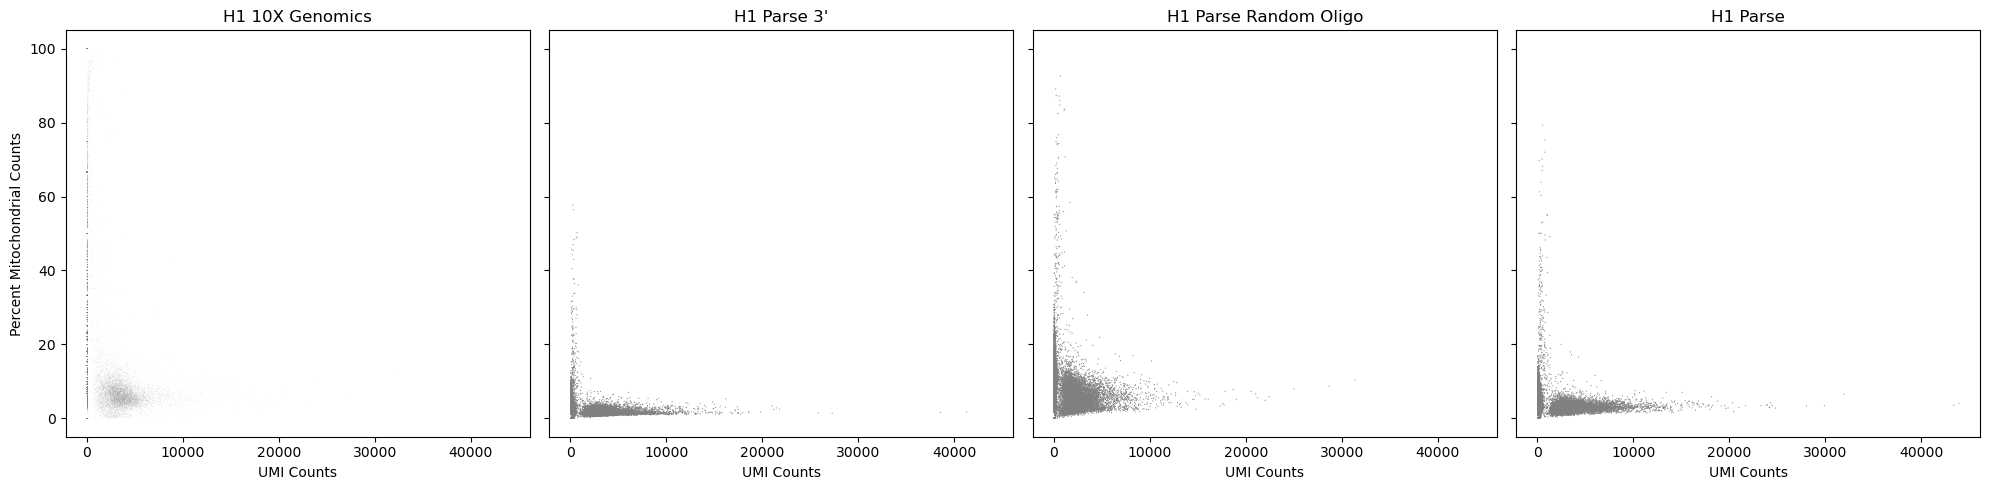

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)
for i, data in enumerate(raw_datasets):
    plotting.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


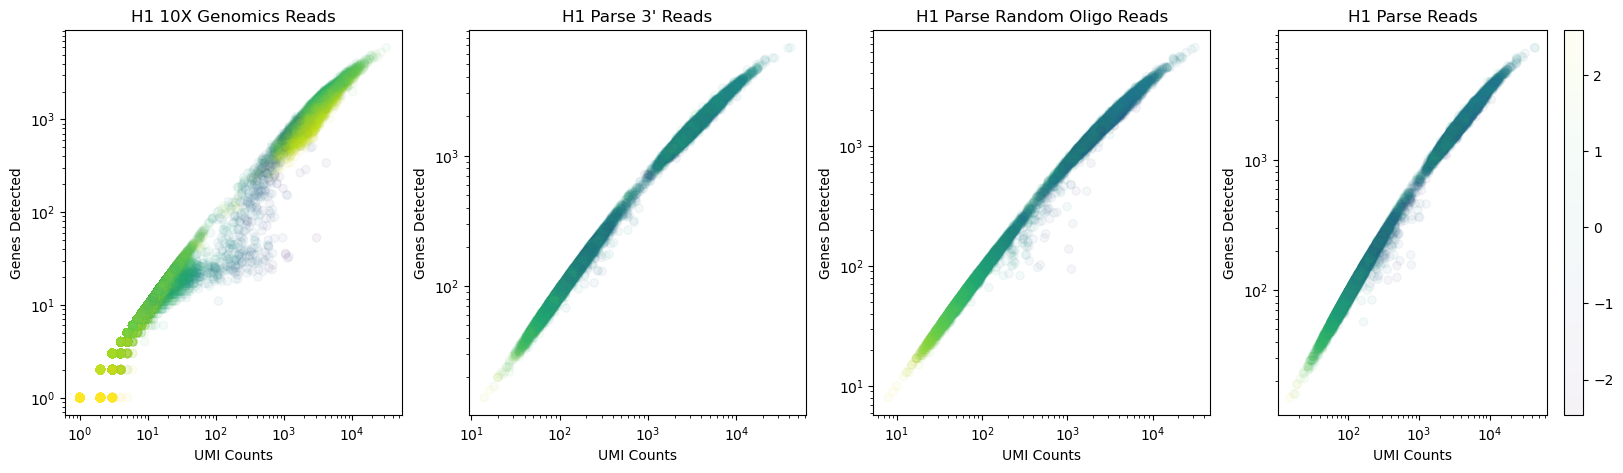

In [14]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    x = np.asarray(data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(data.X>0, axis=1))[:,0]

    ribo_content = np.log(data.obs['percent_ribo']).tolist()

    im = ax.scatter(x, y, c=ribo_content, cmap = 'viridis', alpha=0.05)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


In [15]:
def get_mean_distance(data, ribo_thresh = None, distance = cosine_distances):
    if ribo_thresh:
        data = data[data.obs['percent_ribo'] < ribo_thresh]
    mean_cell = np.asarray(data.X.mean(axis=0))
    dist = distance(data.X, mean_cell)
    return data, dist

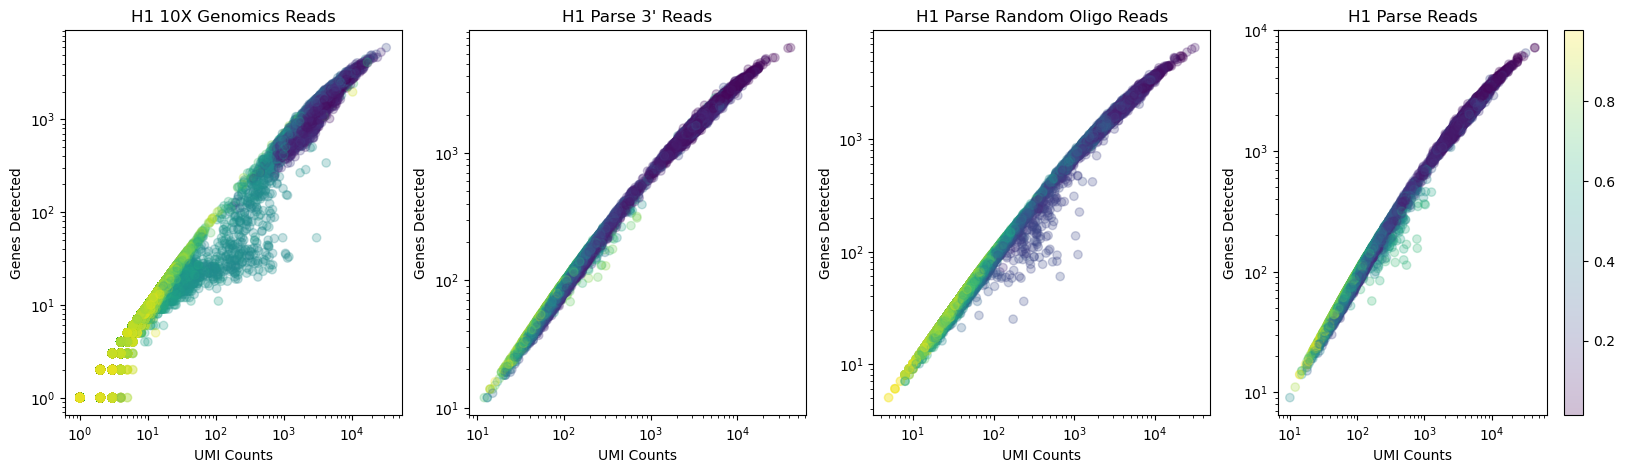

In [16]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    filtered_data, dist = get_mean_distance(data)
    x = np.asarray(filtered_data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(filtered_data.X>0, axis=1))[:,0]

    im = ax.scatter(x, y, c=dist, cmap = 'viridis', alpha=0.25)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


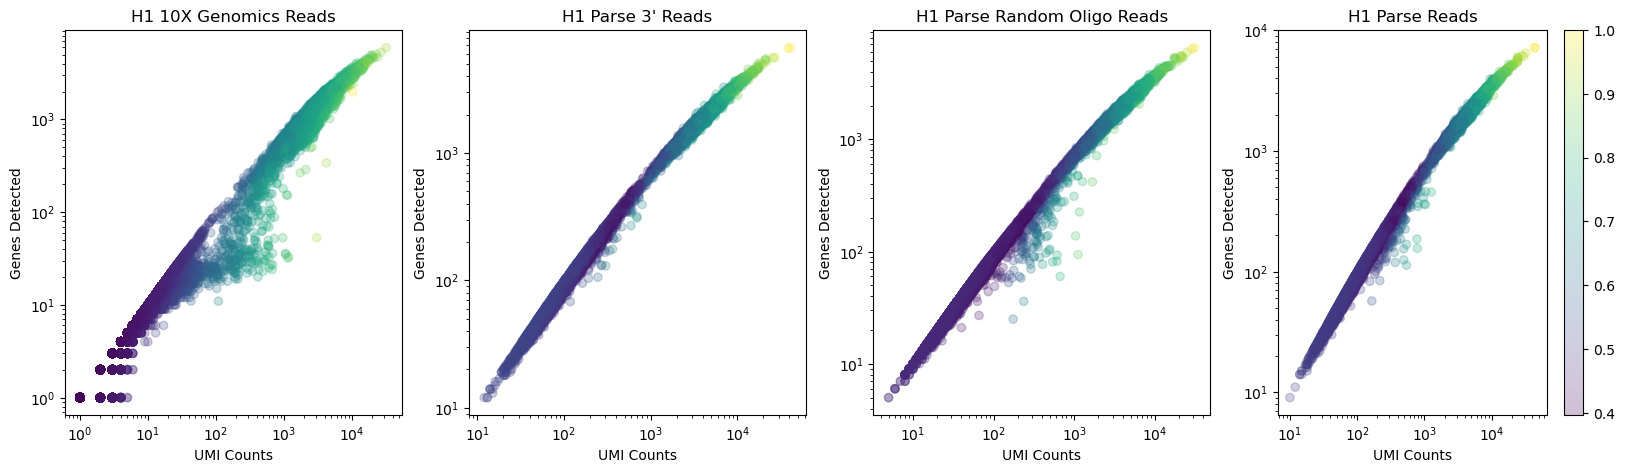

In [17]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    filtered_data, dist = get_mean_distance(data, distance = euclidean_distances)
    dist = np.log(dist) / np.max(np.log(dist))
    x = np.asarray(filtered_data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(filtered_data.X>0, axis=1))[:,0]

    im = ax.scatter(x, y, c=dist, cmap = 'viridis', alpha=0.25)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


8,897 cells passed the 100 UMI threshold for H1 10X Genomics
9,419 cells passed the 500 UMI threshold for H1 Parse 3'
9,383 cells passed the 500 UMI threshold for H1 Parse Random Oligo
9,477 cells passed the 500 UMI threshold for H1 Parse


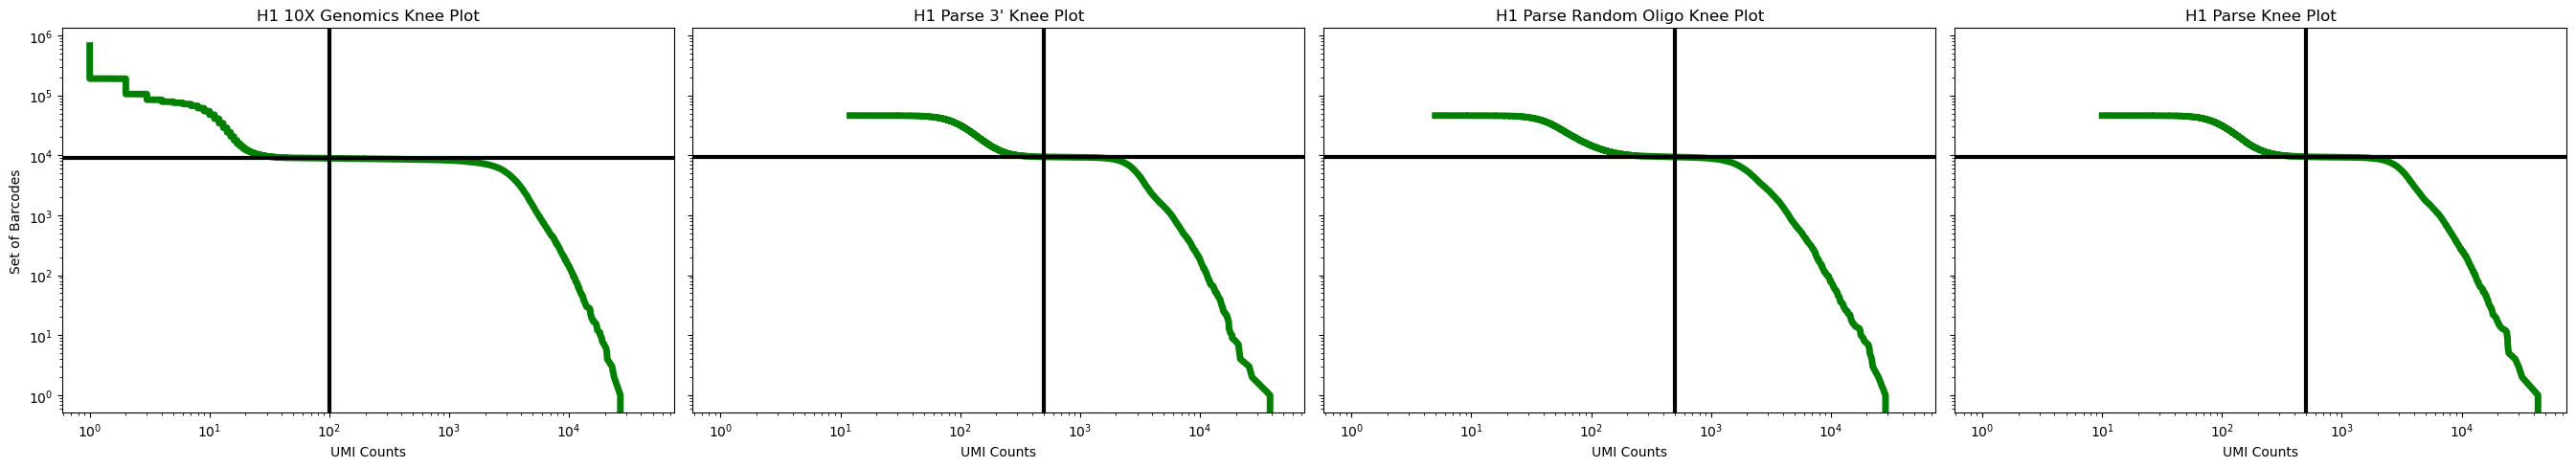

In [18]:
cutoffs = [100, 500, 500, 500]
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()


In [20]:
full_gene_info_path = project_dir / analysis_dir
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)


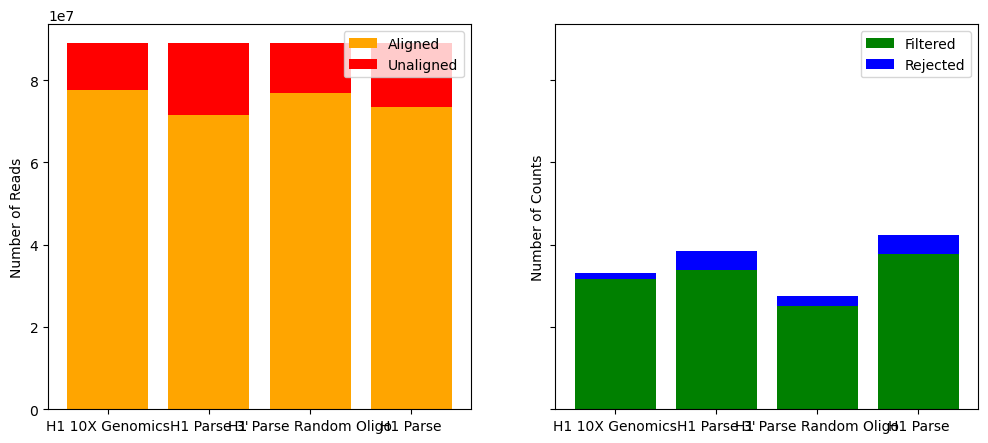

In [21]:
plotting.plot_filtering_metrics(datasets)


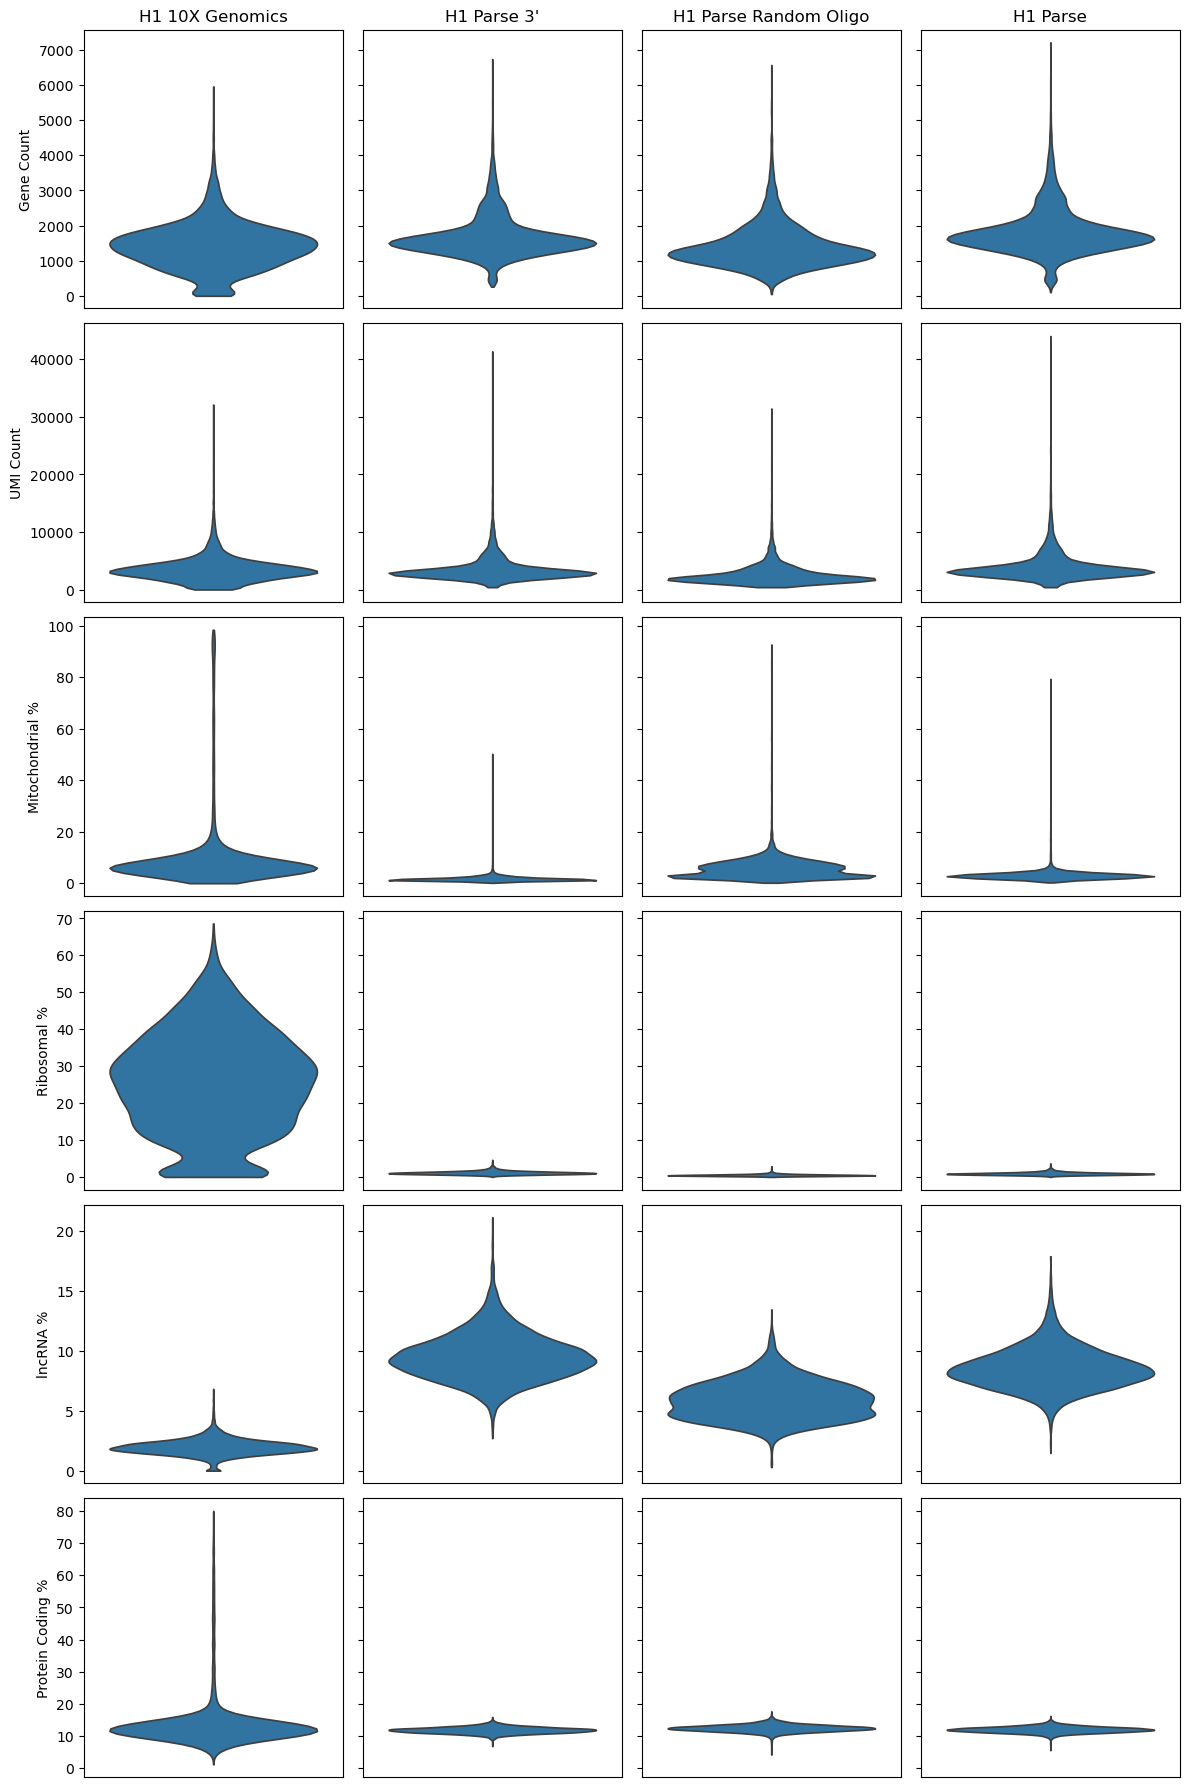

In [22]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))


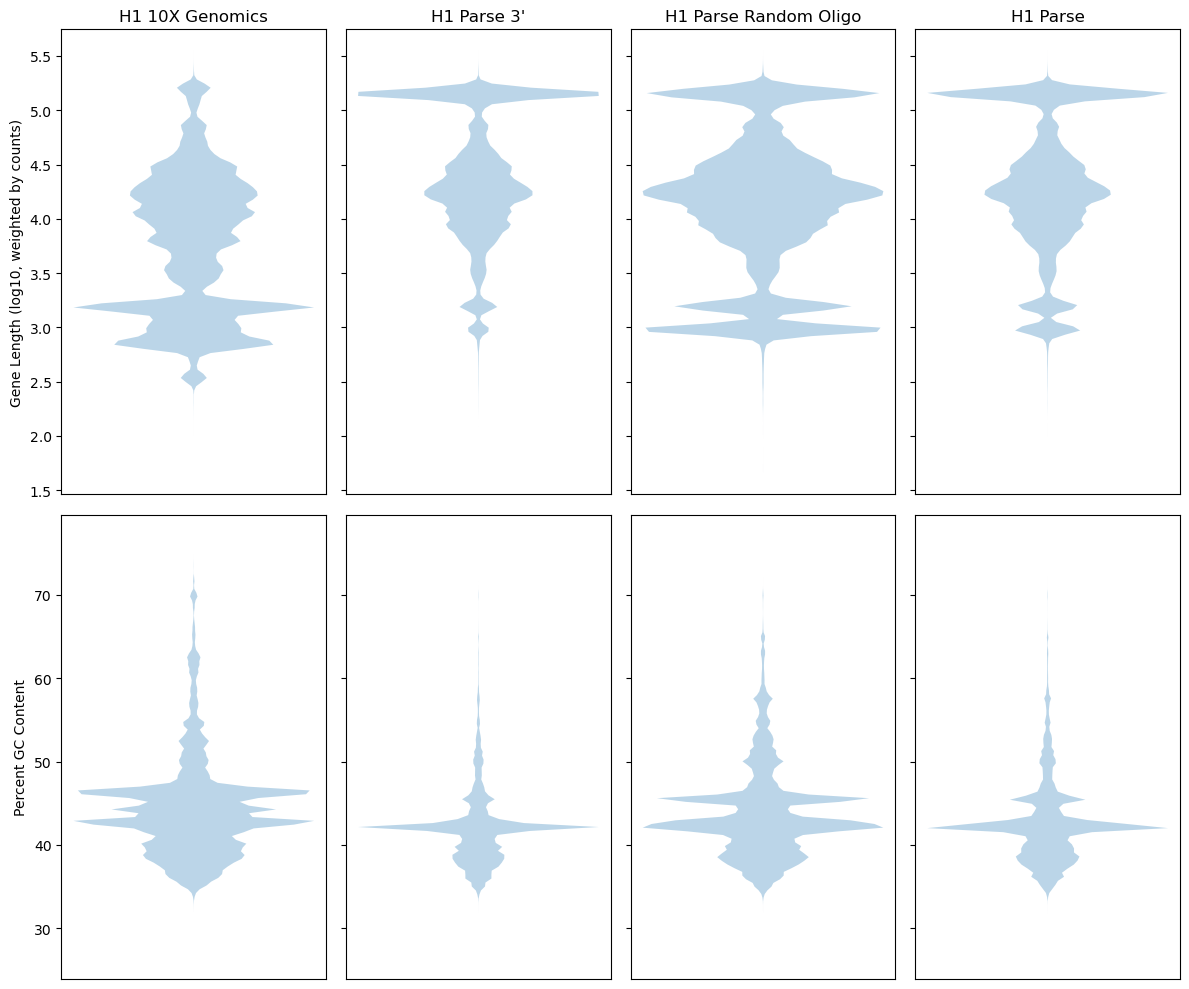

In [23]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)


# Doublet Detection Comparison

In [24]:
scrubs = plotting.detect_doublets(datasets)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.42
Detected doublet rate = 3.3%
Estimated detectable doublet fraction = 30.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 10.9%
Elapsed time: 31.1 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.24
Detected doublet rate = 11.8%
Estimated detectable doublet fraction = 60.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 19.4%
Elapsed time: 23.4 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.22
Detected doublet rate = 13.3%
Estimated detectable doublet fraction = 64.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 20.6%
Elapsed time: 20.7 seconds
Preprocessing...
Simulatin

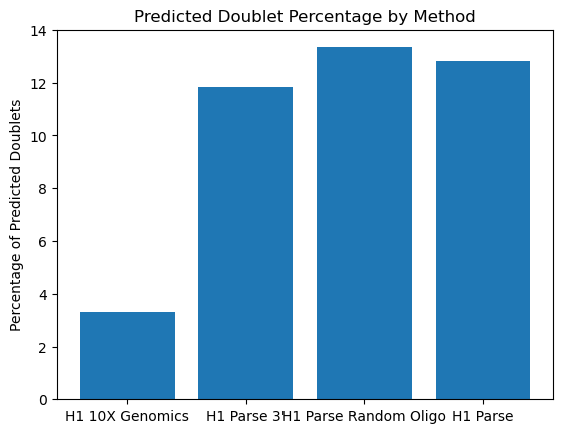

In [25]:
bottom = np.zeros(len(datasets))
titles = [data.uns['title'] for data in datasets]
percent_doublets = [data.obs['predicted_doublet'].sum()/len(data.obs)*100 for data in datasets]

plt.bar(titles, percent_doublets)
plt.ylabel('Percentage of Predicted Doublets')
plt.title('Predicted Doublet Percentage by Method')

plt.show()


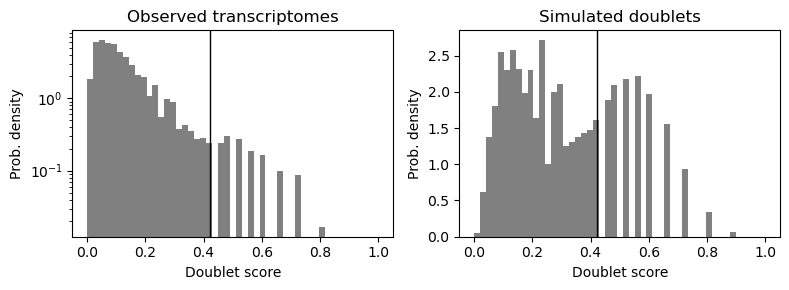

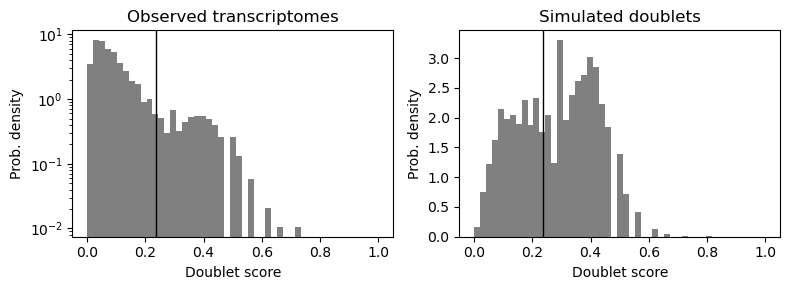

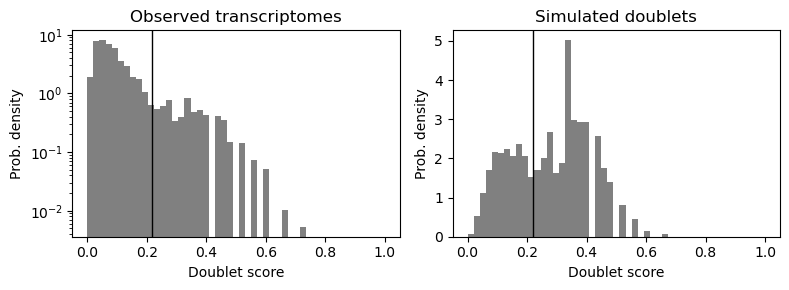

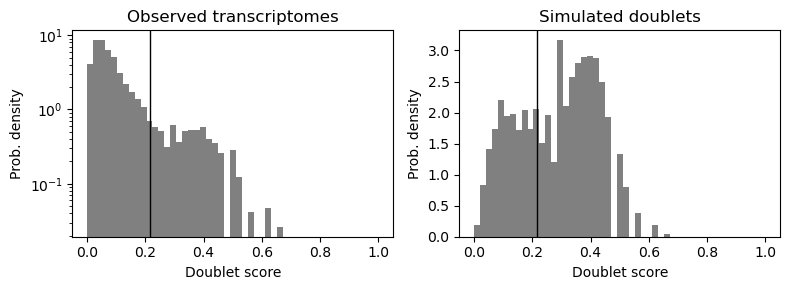

In [26]:
# Should see two peaks separated by threshold
for scrub in scrubs:
    scrub.plot_histogram()

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use

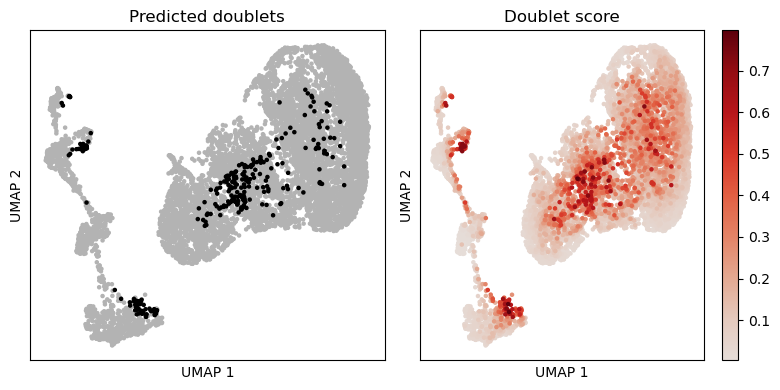

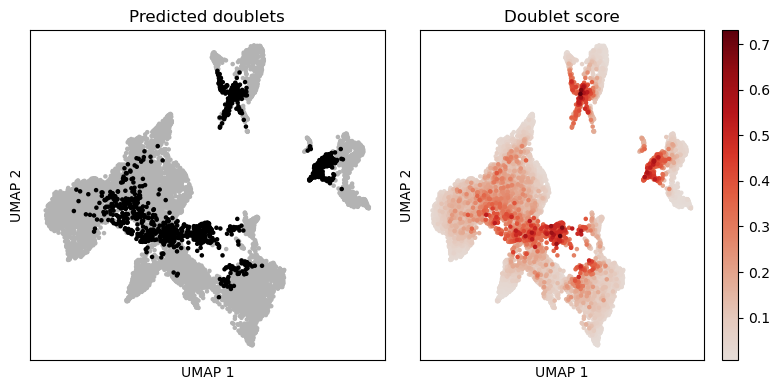

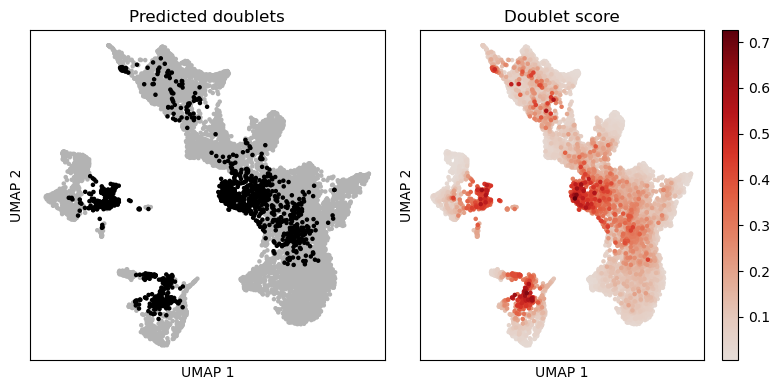

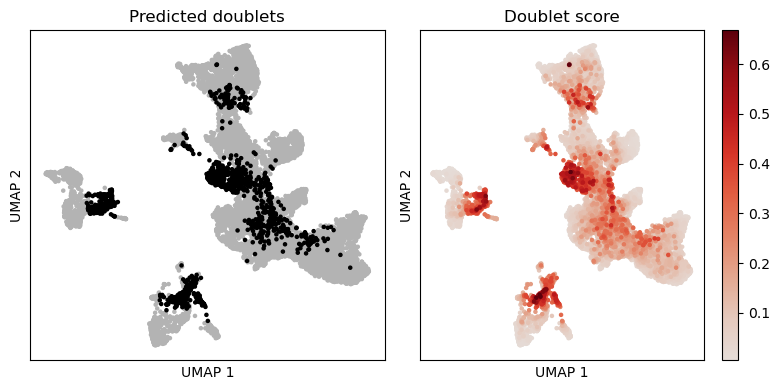

In [27]:
# Should see clustering of doublets
for scrub in scrubs:
    scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3)) 
    scrub.plot_embedding('UMAP', order_points=True)

# Read/Gene Comparisons

In [28]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G','CD3E', 'CD4', 'CD8A', 'CD8B']
T_markers = ['ENSG00000167286.12', 'ENSG00000160654.11', 
             'ENSG00000198851.10', 'ENSG00000010610.10', 
             'ENSG00000153563.17', 'ENSG00000172116.23']

B_marker_names = ['CD19', 'CD24', 'CD40', 'CD72']
B_markers = ['ENSG00000177455.15', 'ENSG00000272398.6'
             'ENSG00000101017.15', 'ENSG00000137101.14']

NK_marker_names = ['FCGR3A', 'FCGR3B', 'NCAM1']
NK_markers = ['ENSG00000203747.13', 'ENSG00000162747.13', 'ENSG00000149294.18']

monocyte_marker_names = ['CD14'] # and CD16
monocyte_markers = ['ENSG00000170458.15']

markers = T_markers + B_markers + NK_markers + monocyte_markers
marker_names = T_marker_names + B_marker_names + NK_marker_names + monocyte_marker_names

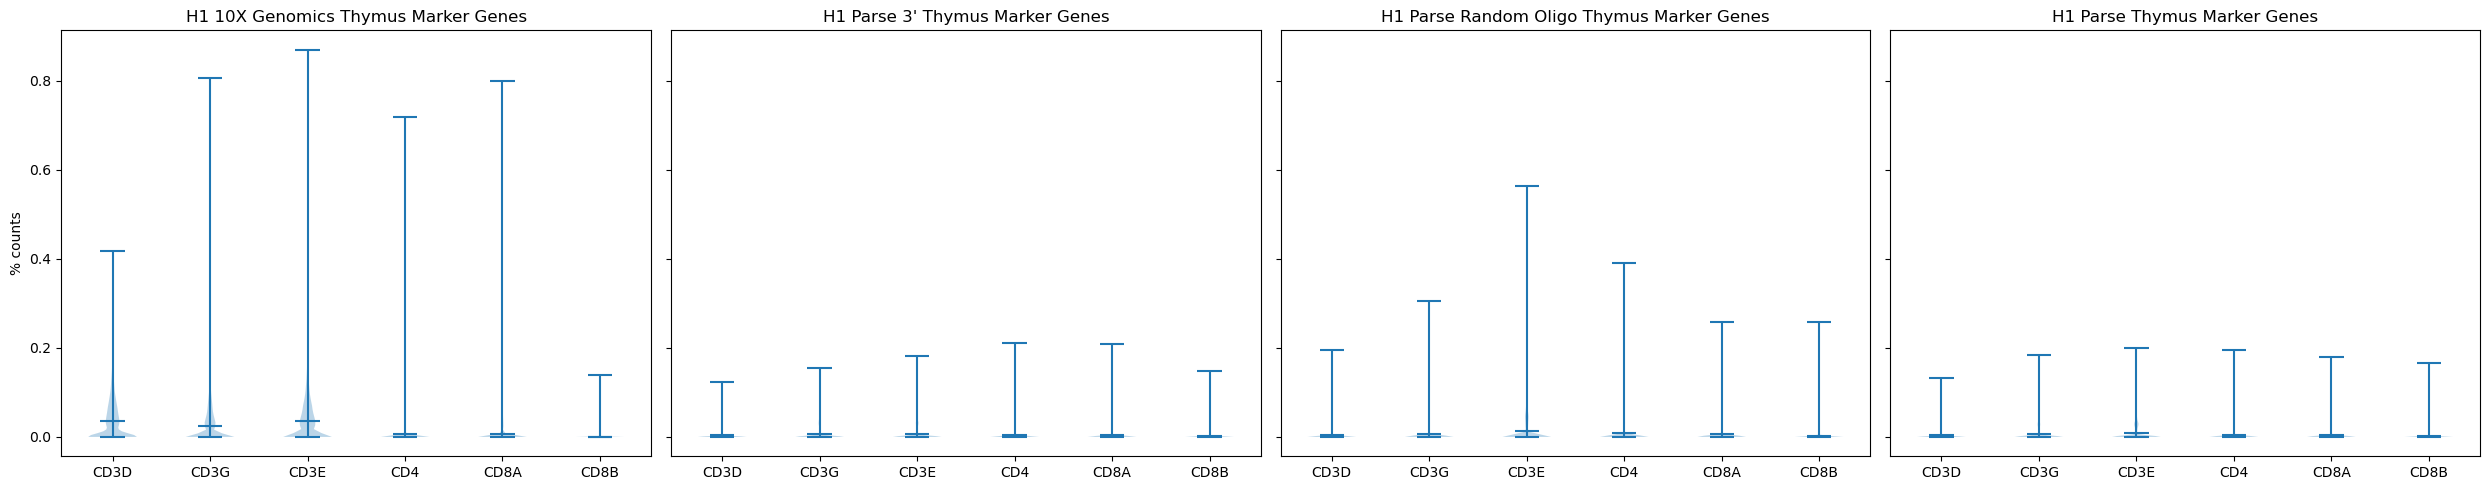

In [29]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.marker_genes(ax[i], data, T_marker_names)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()


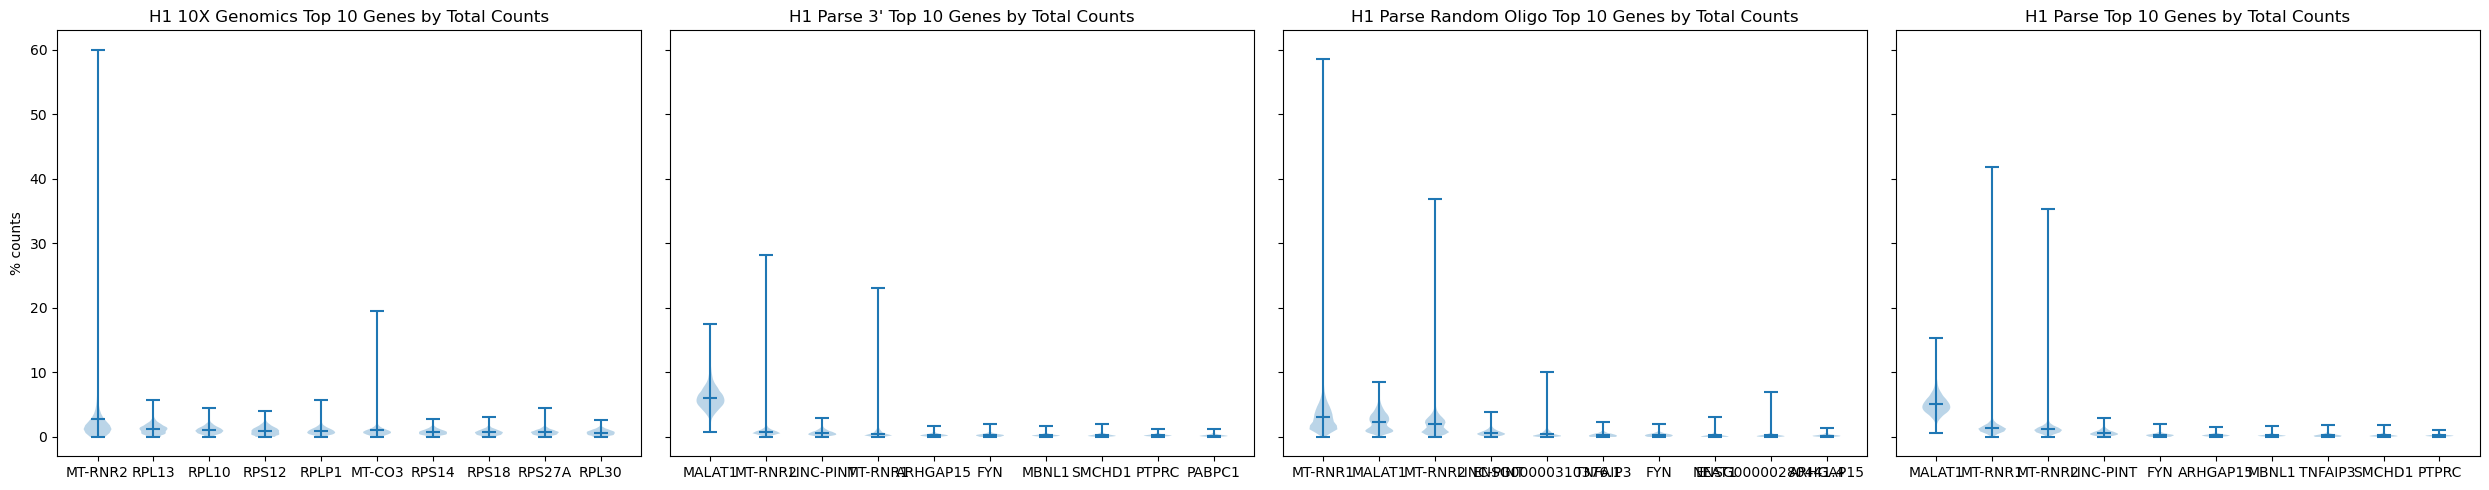

In [30]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()


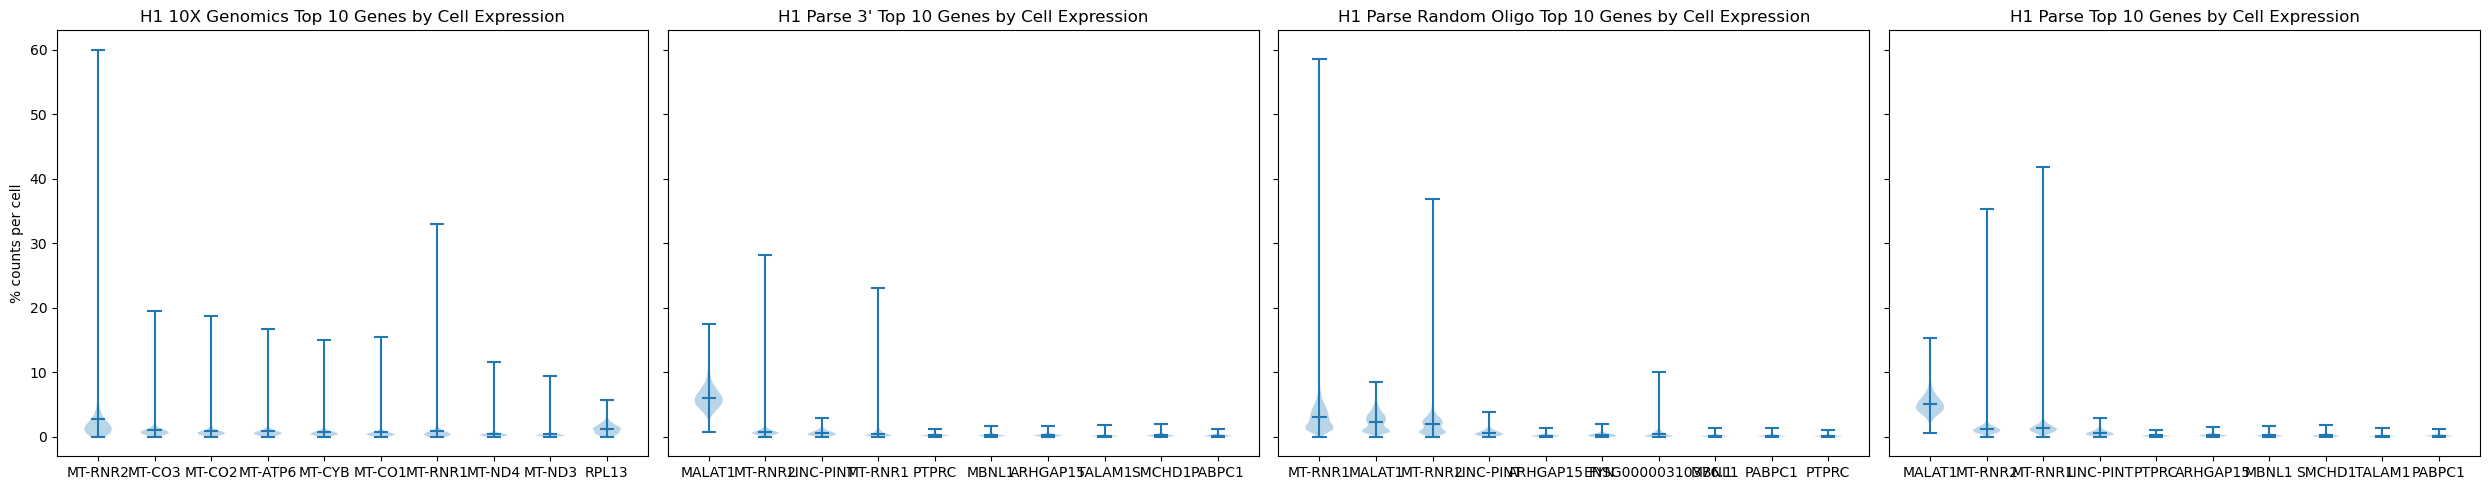

In [31]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()


In [ ]:
compare_names, compare_dfs = plotting.compare(datasets, 8)


In [ ]:
_, _ = plotting.compare(datasets, 1.5)


In [ ]:
_, _ = plotting.compare(datasets, 0.5)


In [ ]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.mergeByCooks(gene_info, name, df)

full_gene_info_path = 'gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)


In [ ]:
cell_thresh = 10
contents = plotting.generate_upset(datasets, gene_info, cell_thresh)


In [ ]:
# Extract gene subsets that were interesting in the upset plot

set_names = ['10X', 'Parse and Parse Random Oligo', '10X, Parse, and Parse Random Oligo', 'All Methods']
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

tech_vals = ['10x', 'polyT', 'randO', 'parse']
tech_keys = [data.uns['name'] for data in datasets]
techs = dict(zip(tech_vals, tech_keys))

genes_10x = contents['gene_ids'][contents[techs['10x']]& 
                                ~contents[techs['polyT']]&
                                ~contents[techs['randO']]&
                                ~contents[techs['parse']]]
genes_10x = genes_10x.tolist()

genes_PO = contents['gene_ids'][~contents[techs['10x']]& 
                            ~contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_PO = genes_PO.tolist()

genes_XPO = contents['gene_ids'][contents[techs['10x']]& 
                            ~contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_XPO = genes_XPO.tolist()

genes_all = contents['gene_ids'][contents[techs['10x']]& 
                            contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_all = genes_all.tolist()

gene_sets = [genes_10x, genes_PO, genes_XPO, genes_all]
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)


In [ ]:
# Look at top 1000 genes for each method instead of all
cell_thresh = 10

contents = plotting.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)


In [ ]:
geneset_names = ['10X', 'Parse Methods', 'All Methods']
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

tech_vals = ['10x', 'polyT', 'randO', 'parse']
tech_keys = [data.uns['name'] for data in datasets]
techs = dict(zip(tech_vals, tech_keys))

genes_10x = contents['gene_ids'][contents[techs['10x']]& 
                                ~contents[techs['polyT']]&
                                ~contents[techs['randO']]&
                                ~contents[techs['parse']]]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents[techs['10x']]& 
                                contents[techs['polyT']]&
                                contents[techs['randO']]&
                                contents[techs['parse']]]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents[techs['10x']]& 
                                contents[techs['polyT']]&
                                contents[techs['randO']]&
                                contents[techs['parse']]]
genes_all = genes_all.tolist()

genesets = [genes_10x, genes_POT, genes_all]
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)
